In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Get the dataset
df_averaged = pd.read_csv('../../data/processed/merged_dataset_averaged.csv')

# Drop non numerical values
X = df_averaged.drop(columns=['country_code', 'Name'])

# Scale using fit transform
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Print the first few rows of the scaled data
print(X_scaled[:5])

# Compare with unscaled data
print(X[:5])

# Which scaling method is best for K-Means? StandardScaler?
# Use standard scalar



[[-1.08372628 -1.08012377 -0.75236333 -0.63836049 -0.69498847 -1.01910914
  -0.36223709 -0.77022909 -0.86976436  1.67710948 -0.18314197 -0.79931726
  -0.25        0.55146577 -1.50482257 -0.9072739   0.58837571  0.46305529
  -1.81831133]
 [ 1.1126688   0.92137958  0.83750392 -0.34941635  1.97790515  0.23974006
  -0.30733374  1.86317989 -0.86976436 -0.61394186 -0.36464141 -0.79931726
  -0.25       -0.60661234 -0.85881288 -0.9072739   2.02298101 -0.43148334
   0.69245944]
 [ 1.08808007 -0.88791493  2.11788683 -0.29293819  1.12623781 -0.32589775
   1.23527328  0.79030952  1.39958268  1.84681698  0.94773917  1.41274679
  -0.25        1.6543973  -0.14820222  1.49018564 -1.00563019  0.9103246
   1.14522138]
 [-0.29940598  1.2266191  -0.45381942  3.75676423 -0.84861325 -0.19544042
   0.10532692 -0.0387266  -0.86976436 -0.61394186 -0.47633338 -0.79931726
  -0.25       -0.60661234  1.2730191   1.17052436  0.11017394 -0.69984493
  -1.36554939]
 [ 1.19062611  0.0910815   0.06299442  0.32134377  1.

# Visualising OG set

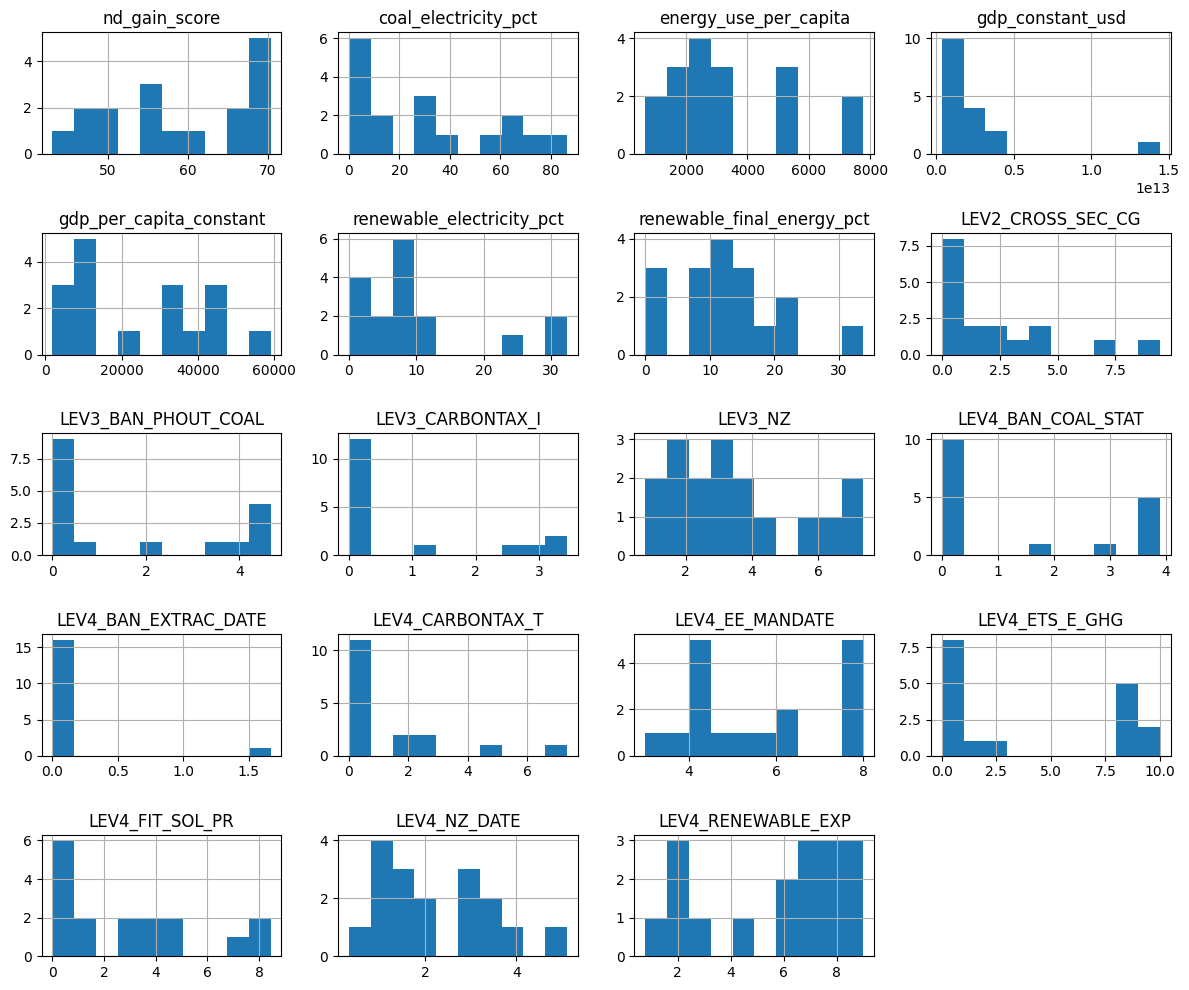

In [10]:
# Simple visualisation of distibution of og set


df_averaged.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


In [11]:


from sklearn.preprocessing import StandardScaler, PowerTransformer
# Apply PowerTransformer (Yeo-Johnson) 
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)

# Final Standardization
scaler = StandardScaler()
X_final = scaler.fit_transform(X_transformed)

# Convert to DataFrame to check results
X_df = pd.DataFrame(X_final, columns=X.columns)
print("New Mean (should be ~0):", X_df.mean().mean())
print("New Std (should be ~1):", X_df.std().mean())

# Compare with the scaling used above
print("Standard Scaled Mean (should be ~0):", X_scaled.mean())
print("Standard Scaled Std (should be ~1):", X_scaled.std())



New Mean (should be ~0): -1.5037850565743227e-18
New Std (should be ~1): 1.0307764064044151
Standard Scaled Mean (should be ~0): -3.849689744830264e-17
Standard Scaled Std (should be ~1): 1.0


In [12]:
# Save the scaled data
scaled_df = pd.DataFrame(X_final, columns=X.columns)
scaled_df.to_csv('../../data/processed/merged_dataset_scaled.csv', index=False)
